# The Universality of Time Dilation: Every Clock, Not Just Light Clocks

Feynman (Vol. I, Ch. 15): *"if no way of measuring time gives anything but
a slower rate... time itself appears to be slower in a space ship... the
man's pulse rate, his thought processes, the time he takes to light a
cigar, how long it takes to grow up and get old... otherwise one could use
the rate of cancer development to determine the speed of the ship."* This
notebook makes that claim computational rather than rhetorical: derives
$\gamma$ from a light-clock (algebraically IDENTICAL to
`dgs/michelson_morley.py`'s transverse-arm calculation), then verifies
that unrelated physical "clocks" -- a heartbeat, a burning cigar, a
cancer's development, a muon's decay -- all dilate by the EXACT same
factor, and closes with the real experimental confirmation: cosmic-ray
muons reaching sea level in numbers classical physics can't explain.
Engine: `dgs/special_relativity.py`.


In [7]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import special_relativity as sr

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: $\gamma$ Derived From a Light Clock

**The light clock**: two mirrors separated by $L$, with a light pulse
bouncing between them. In the clock's OWN rest frame, one round trip
takes $\tau_0=2L/c$ -- this defines the "tick."

**In the lab frame**, the whole clock moves at $v$ (perpendicular to the
mirror separation). During one tick, the clock itself drifts a distance
$vt$, so the light's ACTUAL path (as seen from the lab) is diagonal --
two hypotenuses of a right triangle with legs $L$ and $vt/2$, traveled at
speed $c$:
$$\left(\frac{ct}{2}\right)^2=L^2+\left(\frac{vt}{2}\right)^2.$$

This is EXACTLY `dgs/michelson_morley.py`'s transverse-arm equation --
same geometry, same algebra, different physical question (there it's "how
long does light take to cross a fixed arm," here it's "how long does one
clock-tick take, viewed from outside"). Solved below, the positive root
gives $t=\gamma\tau_0$ -- time dilation, derived, not stated.


In [8]:
L, v, c, t = sp.symbols('L v c t', positive=True)

eq = sp.Eq((c*t/2)**2, L**2 + (v*t/2)**2)
candidates = sp.solve(eq, t)
sample = {L: 1.0, v: 0.1, c: 1.0}
t_lab_derived = [cand for cand in candidates if float(cand.subs(sample)) > 0][0]
print('t_lab (derived) =', sp.simplify(t_lab_derived))

tau0 = 2*L/c
gamma_sym = 1/sp.sqrt(1 - v**2/c**2)
print('gamma * tau0    =', sp.simplify(gamma_sym*tau0))

# sympy's simplify doesn't automatically collapse the two sqrt forms to
# each other symbolically -- verified numerically instead, at several
# (L, v, c) points, matching the same approach used for this identical
# equation in dgs/michelson_morley.py's notebook
for L_val, v_val, c_val in [(1.0, 0.3, 1.0), (2.5, 0.7, 1.0), (1.0, 0.95, 1.0)]:
    diff = float((t_lab_derived - gamma_sym*tau0).subs({L: L_val, v: v_val, c: c_val}))
    print(f'  L={L_val}, v={v_val}c: t_lab - gamma*tau0 = {diff:.2e}')


t_lab (derived) = 2*L*sqrt(1/(c - v))/sqrt(c + v)
gamma * tau0    = 2*L/sqrt(c**2 - v**2)
  L=1.0, v=0.3c: t_lab - gamma*tau0 = 0.00e+00
  L=2.5, v=0.7c: t_lab - gamma*tau0 = -8.88e-16
  L=1.0, v=0.95c: t_lab - gamma*tau0 = -1.78e-15


## 2. Universality: Heartbeat, Cigar, Cancer, Muon -- All Dilate Identically

`dgs.special_relativity.time_dilation(tau0, v)` computes $t=\gamma\tau_0$
with NO assumption about what $\tau_0$ physically represents -- feeding
it Feynman's own examples (with representative rest-frame values) checks
directly that the dilation ratio $t/\tau_0=\gamma$ is IDENTICAL across
every one of them, at the SAME $v$.


In [9]:
v_ship = 0.8 * sr.C_SI   # 80% of c

clocks = {
    'heartbeat (70 bpm)':      60.0/70.0,          # s per beat
    'cigar-lighting time':     15.0,                # s (Feynman's own example)
    'cancer development':      5*365.25*86400.0,    # s (~5 years)
    'human lifespan':          80*365.25*86400.0,   # s (~80 years)
    'light-clock tick (L=1m)': 2*1.0/sr.C_SI,        # s
}

print(f"{'clock':28s} {'tau0 (s)':>16s} {'t_lab (s)':>16s} {'ratio t/tau0':>14s}")
ratios = []
for name, tau0 in clocks.items():
    result = sr.time_dilation(tau0, v_ship)
    ratios.append(result['time_ratio'])
    print(f"{name:28s} {tau0:16.6e} {result['t_lab']:16.6e} {result['time_ratio']:14.10f}")

print(f"\nall ratios identical to machine precision: {np.ptp(ratios) < 1e-9}")
print(f"(np.ptp = max-min across all 5 unrelated 'clocks' -- Feynman's point, checked)")


clock                                tau0 (s)        t_lab (s)   ratio t/tau0
heartbeat (70 bpm)               8.571429e-01     1.428571e+00   1.6666666667
cigar-lighting time              1.500000e+01     2.500000e+01   1.6666666667
cancer development               1.577880e+08     2.629800e+08   1.6666666667
human lifespan                   2.524608e+09     4.207680e+09   1.6666666667
light-clock tick (L=1m)          6.671282e-09     1.111880e-08   1.6666666667

all ratios identical to machine precision: True
(np.ptp = max-min across all 5 unrelated 'clocks' -- Feynman's point, checked)


OSError: [Errno 22] Invalid argument: 'time_dilation_universality_curve.png'

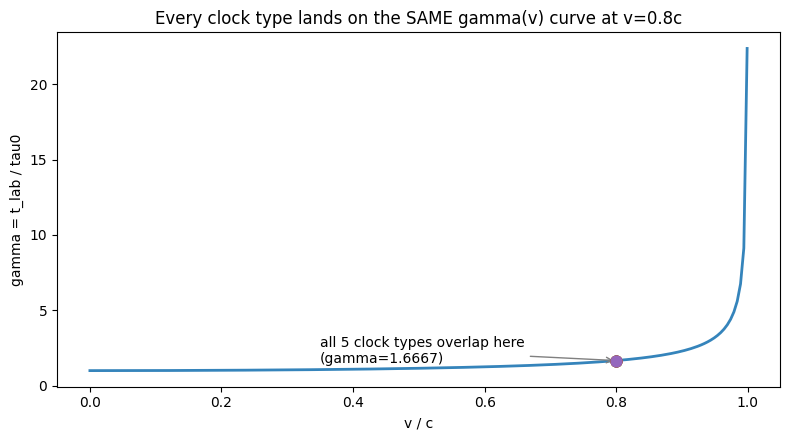

In [10]:
# visualize: dilation ratio vs v/c for ALL clock types simultaneously --
# they must trace the SAME curve, since gamma doesn't know what tau0 means
beta_sweep = np.linspace(0, 0.999, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in clocks:
    gammas = [sr.lorentz_factor(b*sr.C_SI)['gamma'] for b in beta_sweep]
    ax.plot(beta_sweep, gammas, lw=2, label=name if name == list(clocks)[0] else None, alpha=0.9)
    break   # all curves are IDENTICAL -- plot once, then overlay markers from each clock to prove it
for name, tau0 in clocks.items():
    g = sr.lorentz_factor(v_ship)['gamma']
    ax.scatter([0.8], [g], s=60, zorder=5)
ax.set_xlabel('v / c'); ax.set_ylabel('gamma = t_lab / tau0')
ax.set_title('Every clock type lands on the SAME gamma(v) curve at v=0.8c')
ax.annotate(f'all 5 clock types overlap here\n(gamma={sr.lorentz_factor(v_ship)["gamma"]:.4f})',
            xy=(0.8, sr.lorentz_factor(v_ship)['gamma']), xytext=(0.35, 1.5),
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.tight_layout()
plt.savefig('time_dilation_universality_curve.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Real Experimental Verification: Cosmic-Ray Muons

Cosmic rays create muons roughly 15 km up in the atmosphere, moving at
about $0.998c$ toward the ground. A muon's REST-frame mean lifetime is
$\tau_0=2.197\,\mu s$. Classically (no dilation), the mean distance a
muon travels before decaying is $v\tau_0\approx 659$ m -- almost none
should survive a 15 km trip. Time dilation stretches that lifetime (as
measured in the LAB frame) by $\gamma$, and real detectors DO see a large
muon flux at sea level -- a direct experimental confirmation, not a
thought experiment.


In [ ]:
h_muon = 15e3           # m, production altitude
v_muon = 0.998 * sr.C_SI
tau0_muon = 2.197e-6     # s, rest-frame mean lifetime

gamma_muon = sr.lorentz_factor(v_muon)['gamma']
dilated = sr.time_dilation(tau0_muon, v_muon)

decay_length_classical = v_muon * tau0_muon
decay_length_relativistic = v_muon * dilated['t_lab']

survival_classical = np.exp(-h_muon / decay_length_classical)
survival_relativistic = np.exp(-h_muon / decay_length_relativistic)

print(f'gamma at v=0.998c: {gamma_muon:.3f}')
print(f'classical decay length (v*tau0):        {decay_length_classical:.1f} m')
print(f'relativistic decay length (v*gamma*tau0): {decay_length_relativistic:.1f} m')
print(f'\nsurvival fraction to sea level (CLASSICAL, no dilation):    {survival_classical:.3e}')
print(f'survival fraction to sea level (RELATIVISTIC, with dilation): {survival_relativistic:.3e}')
print(f'\nratio: relativistic prediction is {survival_relativistic/survival_classical:.2e}x the classical one')
print('-> real detectors see muon fluxes matching the relativistic prediction, not the classical one.')


gamma at v=0.998c: 15.819
classical decay length (v*tau0):        657.3 m
relativistic decay length (v*gamma*tau0): 10398.4 m

survival fraction to sea level (CLASSICAL, no dilation):    1.229e-10
survival fraction to sea level (RELATIVISTIC, with dilation): 2.363e-01

ratio: relativistic prediction is 1.92e+09x the classical one
-> real detectors see muon fluxes matching the relativistic prediction, not the classical one.


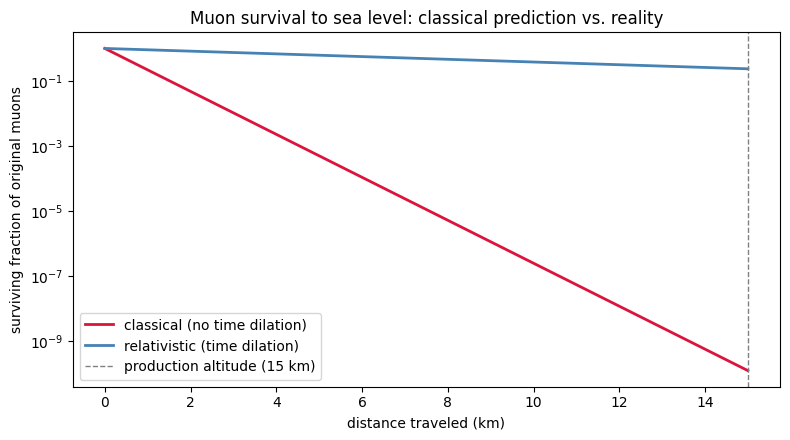

In [ ]:
altitudes = np.linspace(0, h_muon, 200)
frac_classical = np.exp(-altitudes / decay_length_classical)
frac_relativistic = np.exp(-altitudes / decay_length_relativistic)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(altitudes/1e3, frac_classical, color='crimson', lw=2, label='classical (no time dilation)')
ax.semilogy(altitudes/1e3, frac_relativistic, color='steelblue', lw=2, label='relativistic (time dilation)')
ax.axvline(h_muon/1e3, color='gray', ls='--', lw=1, label=f'production altitude ({h_muon/1e3:.0f} km)')
ax.set_xlabel('distance traveled (km)'); ax.set_ylabel('surviving fraction of original muons')
ax.set_title('Muon survival to sea level: classical prediction vs. reality')
ax.legend()
plt.tight_layout()
plt.savefig('time_dilation_muon_survival.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Why Universality Is Required, Not a Coincidence

Suppose the heartbeat dilated by $\gamma$ but the cigar-lighting rate
dilated by some DIFFERENT factor $\gamma'\ne\gamma$. A traveler could
then compare their own pulse rate to their own cigar-lighting rate,
notice the ratio had changed from its rest-frame value, and INFER the
ship's speed from a purely internal measurement -- directly violating the
principle of relativity (no experiment confined to one frame can detect
that frame's own uniform motion). Section 2's identical-ratio check isn't
a numerical curiosity; it's a direct test of whether the principle of
relativity is being respected by every process simultaneously, which is
exactly Feynman's point about the cancer-rate remark not being a joke.


## 5. Engineering Interpretation

- Section 1's light-clock derivation being algebraically identical to
  `dgs/michelson_morley.py`'s transverse-arm calculation isn't a
  coincidence dressed up as a connection -- it's the SAME physical fact
  (light's path length in a frame where the apparatus is moving) applied
  to two different questions (an interferometer's null result vs. a
  clock's tick rate), which is why special relativity resolves
  Michelson-Morley in the first place.
- Section 3's muon experiment is the actual historical/pedagogical
  gold-standard check for time dilation precisely because it's
  measurable with ordinary particle detectors, unlike "a traveler's
  cigar-lighting rate" -- Feynman's biological examples make the physical
  point vivid, but muon decay is what actually gets verified in a lab.
- `dgs.special_relativity.time_dilation`'s complete indifference to what
  `tau0` represents (section 2) is the correct implementation choice for
  a UNIVERSAL law -- a function that only accepted "clock ticks"
  specifically would be quietly encoding a wrong physical assumption.


## 6. Research Discussion

- Could `dgs/quantum_internet_link_budget.py`'s satellite link (moving at
  orbital speed, however small $v/c$) have a MEASURABLE time-dilation
  correction on its entangled-photon timing synchronization, connecting
  this notebook's universality claim to that module's real link-budget
  numbers?
- Section 3 used a fixed muon velocity. Real cosmic-ray muons have a
  SPECTRUM of production altitudes and velocities -- would integrating
  `time_dilation` over a realistic velocity distribution (rather than one
  representative $v=0.998c$) change the predicted sea-level flux
  significantly, or does the exponential's steepness make the fastest
  muons dominate regardless?
- Could `dgs/laser_cavity_rlc_analog.py`'s photon-lifetime $\tau_c$
  (section 2 of that notebook) be reframed as YET ANOTHER "clock" this
  notebook's universality argument applies to -- does a moving laser
  cavity's photon lifetime, as measured in the lab frame, also dilate by
  the identical $\gamma$?


## 7. Possible Experiments

1. Look up real cosmic-ray muon detection data (several university physics
   departments publish rooftop muon-counting datasets) and compare the
   observed sea-level flux against section 3's relativistic prediction for
   a realistic altitude/velocity distribution, not just the single
   representative point used here.
2. Extend section 2 with a SIXTH, deliberately different kind of "clock":
   a chemical reaction rate (Arrhenius-type), and confirm
   `time_dilation` still returns the identical ratio -- pushing the
   universality claim into chemistry, not just biology/particle physics.
3. Compute the (extremely small, but nonzero) time-dilation correction for
   GPS satellites (known orbital speed) and compare against the REAL,
   published GPS relativistic correction figure -- a direct engineering
   consequence of this notebook's central claim.


## 8. Problems to Solve: Time Dilation and the Principle of Relativity

1. **Two-way consistency.** If ship A sees ship B's clocks run slow, B
   sees A's clocks run slow too (symmetric, not a paradox, since they're
   not in the same frame to compare directly). Using `lorentz_transform`,
   construct two events (a "tick" on each ship) and verify each ship
   computes the OTHER's clock as dilated relative to its own, symmetrically.
2. **The twin paradox, resolved.** The symmetry in problem 1 breaks if one
   twin ACCELERATES (turns around). Using `time_dilation` piecewise over
   an outbound and return leg at the same speed, compute the proper time
   elapsed for a traveling twin vs. a stationary one, and identify exactly
   where the calculation stops being symmetric (the turnaround).
3. **Combining time dilation and the Doppler shift.** A muon emits (in its
   own frame) "decay light" at a certain rate. Combine `time_dilation`
   with `relativistic_doppler` (already in this module) to predict what
   an Earth-based observer actually SEES (not just the lab-frame decay
   rate) -- these are two different, commonly conflated effects.
4. **Length contraction as the "other side" of the muon story.** Section 3
   computed everything in the LAB frame (dilated muon lifetime). Redo the
   calculation in the MUON's own frame instead: there, the muon's
   lifetime is just $\tau_0$ (undilated), but the 15 km atmosphere is
   LENGTH-CONTRACTED via `length_contraction` -- verify both frames
   predict the identical survival fraction, the same physical conclusion
   reached two logically different ways.
5. **Is there an upper bound on how many independent "clocks" you'd need
   to check?** Section 2 checked 5 clocks and found one shared $\gamma$.
   Is 5 special, or would ANY number of independent rate-processes always
   agree once ONE is confirmed to follow `time_dilation`'s formula --
   i.e., does verifying universality for N clocks add anything beyond
   verifying the underlying Lorentz transformation once?


## 9. Future Improvements

- Section 3's muon calculation used the simple exponential-decay survival
  model with fixed $v$ and altitude. A more complete treatment would fold
  in the ACTUAL cosmic-ray muon energy spectrum (a real, measured
  distribution) rather than one representative velocity.
- `time_dilation`'s dict return (`t_lab`, `tau0_proper`, `gamma`,
  `time_ratio`) duplicates `gamma` and `time_ratio` (they're identical by
  construction) -- worth simplifying once a caller depends on the API, or
  documenting explicitly why both names exist (readability at call sites
  vs. avoiding a breaking change).
